# Detecção de Discurso de Ódio em Português com SVM — ToLD-BR

Este notebook aplica **Support Vector Machine (SVM)** com vetorização **TF-IDF** à base **ToLD-BR**, como parte de um estudo comparativo de abordagens para detecção de discurso de ódio em textos em português.

**Configurações padronizadas entre todos os modelos:**
- Dataset: ToLD-BR (carregado via GitHub)
- Split: 80% treino / 20% teste, com `stratify=y` e `random_state=42`
- Pré-processamento: lowercase, remoção de URLs, menções, pontuação e números
- Binarização: qualquer pontuação ofensiva ≥ 1 em qualquer categoria → ofensivo
- Métrica principal: F1-score macro

## 1. Importações

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, confusion_matrix, f1_score

## 2. Carregamento da base de dados

A base ToLD-BR é carregada diretamente do repositório no GitHub. Contém tweets em português anotados para seis categorias de conteúdo ofensivo, com pontuação proporcional ao número de anotadores (0–3) que identificaram cada categoria.

In [2]:
url = 'https://raw.githubusercontent.com/JAugusto97/ToLD-Br/main/ToLD-BR.csv'
df = pd.read_csv(url)

print(f'Colunas disponíveis: {df.columns.tolist()}')
print(f'Total de amostras: {len(df)}')
df.head()

Colunas disponíveis: ['text', 'homophobia', 'obscene', 'insult', 'racism', 'misogyny', 'xenophobia']
Total de amostras: 21000


,text,homophobia,obscene,insult,racism,misogyny,xenophobia
0,Meu nivel de amizade com isis é ela ter meu in...,0.0,0.0,2.0,0.0,0.0,0.0
1,"rt @user @user o cara adultera dados, que fora...",0.0,0.0,1.0,0.0,0.0,0.0
2,@user @user @user o cara só é simplesmente o m...,0.0,2.0,1.0,0.0,0.0,0.0
3,eu to chorando vei vsf e eu nem staneio izone ...,0.0,1.0,0.0,0.0,0.0,0.0
4,Eleitor do Bolsonaro é tão ignorante q não per...,0.0,1.0,2.0,0.0,0.0,0.0


## 3. Binarização dos rótulos

Amostras com pontuação ≥ 1 em **qualquer** categoria ofensiva são rotuladas como ofensivas (`label = 1`); caso contrário, como não-ofensivas (`label = 0`).

In [3]:
offensive_cols = ['homophobia', 'obscene', 'insult', 'racism', 'misogyny', 'xenophobia']

df['label'] = (df[offensive_cols].max(axis=1) >= 1).astype(int)

print(f'Distribuição de classes:\n{df["label"].value_counts()}')
print(f'\nTaxa de conteúdo ofensivo: {df["label"].mean():.1%}')

Distribuição de classes:
label
0    11745
1     9255
Name: count, dtype: int64

Taxa de conteúdo ofensivo: 44.1%


## 4. Pré-processamento de texto

> **Nota:** Stopwords não foram removidas, pois palavras funcionais podem carregar valor contextual relevante para detecção de discurso de ódio.

In [4]:
def preprocess_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    text = re.sub(r'\@\w+|\#\w+', '', text)
    text = re.sub(r'[%s]' % re.escape(string.punctuation), ' ', text)
    text = re.sub(r'\w*\d\w*', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['text_clean'] = df['text'].apply(preprocess_text)
df[['text', 'text_clean']].head()

,text,text_clean
0,Meu nivel de amizade com isis é ela ter meu in...,meu nivel de amizade com isis é ela ter meu in...
1,"rt @user @user o cara adultera dados, que fora...",rt o cara adultera dados que foram desmascarad...
2,@user @user @user o cara só é simplesmente o m...,o cara só é simplesmente o maior vencedor da h...
3,eu to chorando vei vsf e eu nem staneio izone ...,eu to chorando vei vsf e eu nem staneio izone ...
4,Eleitor do Bolsonaro é tão ignorante q não per...,eleitor do bolsonaro é tão ignorante q não per...


## 5. Vetorização com TF-IDF

In [5]:
vectorizer = TfidfVectorizer(max_features=10000, ngram_range=(1, 2))
X = vectorizer.fit_transform(df['text_clean'])
y = df['label']

print(f'Dimensão do vetor TF-IDF: {X.shape}')

Dimensão do vetor TF-IDF: (21000, 10000)


## 6. Divisão treino/teste

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Treinamento: {X_train.shape[0]} amostras')
print(f'Teste:       {X_test.shape[0]} amostras')

Treinamento: 16800 amostras
Teste:       4200 amostras


## 7. Treinamento do modelo SVM

`LinearSVC` é a variante mais eficiente para dados de texto esparsos de alta dimensionalidade.

In [7]:
svm_model = LinearSVC(class_weight='balanced', random_state=42, max_iter=2000)
svm_model.fit(X_train, y_train)

LinearSVC(class_weight='balanced', max_iter=2000, random_state=42)

## 8. Avaliação do modelo

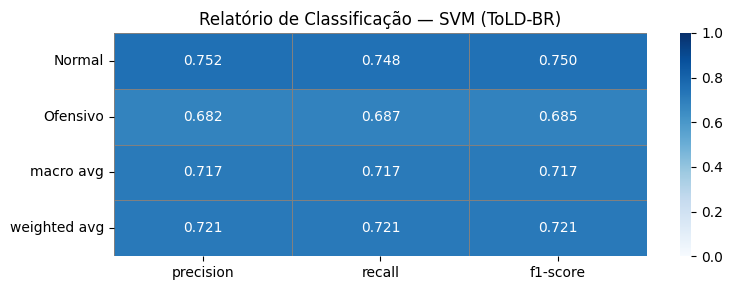

F1-score Macro: 0.7172


In [8]:
y_pred = svm_model.predict(X_test)

# Relatório de classificação como imagem
report_dict = classification_report(y_test, y_pred, target_names=['Normal', 'Ofensivo'], output_dict=True)
df_report = pd.DataFrame(report_dict).T.drop('accuracy', errors='ignore')

fig, ax = plt.subplots(figsize=(8, 3))
sns.heatmap(
    df_report[['precision', 'recall', 'f1-score']].astype(float),
    annot=True, fmt='.3f', cmap='Blues',
    linewidths=0.5, linecolor='gray',
    ax=ax, vmin=0, vmax=1
)
ax.set_title('Relatório de Classificação \u2014 SVM (ToLD-BR)')
plt.tight_layout()
plt.savefig('report_svm_toldbr.png', dpi=150, bbox_inches='tight')
plt.show()

f1_macro = report_dict['macro avg']['f1-score']
print(f'F1-score Macro: {f1_macro:.4f}')

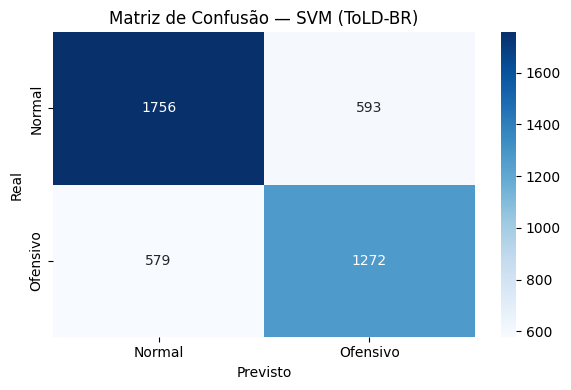

In [9]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Ofensivo'],
            yticklabels=['Normal', 'Ofensivo'])
plt.title('Matriz de Confusão — SVM (ToLD-BR)')
plt.xlabel('Previsto')
plt.ylabel('Real')
plt.tight_layout()
plt.show()

## 9. Tokens mais relevantes por classe

/tmp/ipykernel_171080/939293787.py:19: UserWarning: Glyph 33725 (\N{CJK UNIFIED IDEOGRAPH-83BD}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_171080/939293787.py:19: UserWarning: Glyph 33579 (\N{CJK UNIFIED IDEOGRAPH-832B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_171080/939293787.py:19: UserWarning: Glyph 20040 (\N{CJK UNIFIED IDEOGRAPH-4E48}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/heliocm/.local/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 33725 (\N{CJK UNIFIED IDEOGRAPH-83BD}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/heliocm/.local/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 33579 (\N{CJK UNIFIED IDEOGRAPH-832B}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/heliocm/.local/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 20040 (\N{CJK 

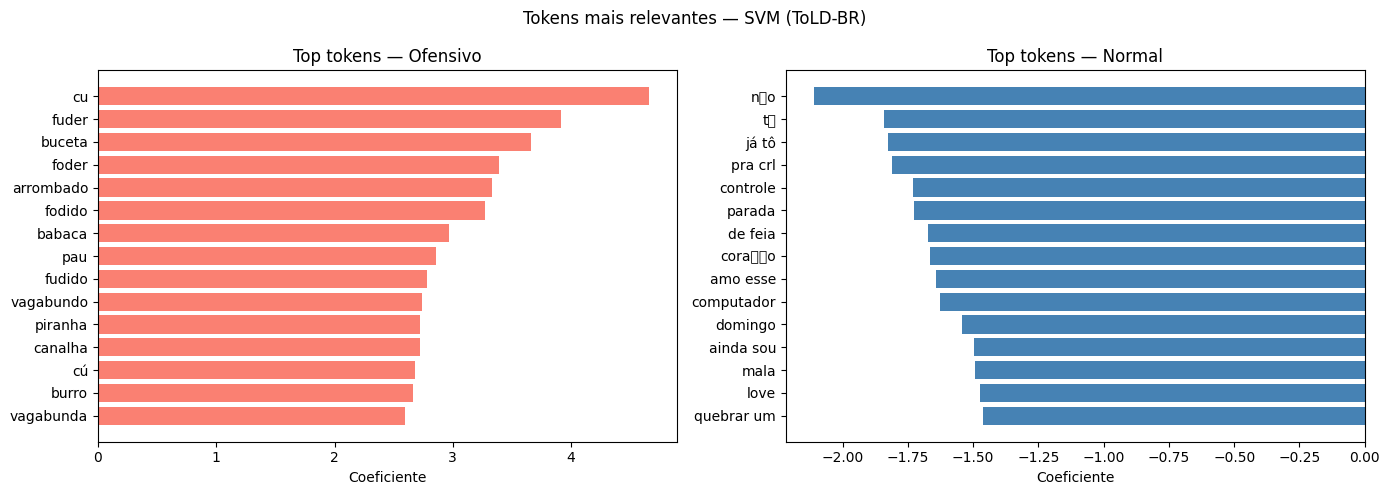

In [10]:
feature_names = vectorizer.get_feature_names_out()
coef = svm_model.coef_[0]
top_n = 15

top_off = np.argsort(coef)[-top_n:][::-1]
top_norm = np.argsort(coef)[:top_n]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(feature_names[top_off][::-1], coef[top_off][::-1], color='salmon')
axes[0].set_title('Top tokens — Ofensivo')
axes[0].set_xlabel('Coeficiente')

axes[1].barh(feature_names[top_norm][::-1], coef[top_norm][::-1], color='steelblue')
axes[1].set_title('Top tokens — Normal')
axes[1].set_xlabel('Coeficiente')

plt.suptitle('Tokens mais relevantes — SVM (ToLD-BR)')
plt.tight_layout()
plt.show()

In [11]:
# ANALISE_QUALITATIVA_PATCH
import pandas as _pd, os as _os
from sklearn.model_selection import train_test_split as _tts

# Reconstrução dos textos de teste (mesmo split determinístico)
_, _idx = _tts(np.arange(len(df)), test_size=0.2,
               stratify=df['label'], random_state=42)
_texts = df['text'].values[_idx]

# Converter y_test para numpy (é pandas Series em LogReg/SVM)
_y_test = np.array(y_test)
_y_pred = np.array(y_pred)

_fp_idx = np.where((_y_test == 0) & (_y_pred == 1))[0]
_fn_idx = np.where((_y_test == 1) & (_y_pred == 0))[0]

_rng = np.random.default_rng(42)
_fp_s = _rng.choice(_fp_idx, size=min(10, len(_fp_idx)), replace=False) if len(_fp_idx) else np.array([], int)
_fn_s = _rng.choice(_fn_idx, size=min(10, len(_fn_idx)), replace=False) if len(_fn_idx) else np.array([], int)

_rows = []
for _i in _fp_s:
    _rows.append({'modelo': 'SVM', 'dataset': 'ToLD-BR',
                   'tipo': 'Falso Positivo', 'texto': _texts[_i],
                   'rotulo_real': int(_y_test[_i]), 'predicao': int(_y_pred[_i])})
for _i in _fn_s:
    _rows.append({'modelo': 'SVM', 'dataset': 'ToLD-BR',
                   'tipo': 'Falso Negativo', 'texto': _texts[_i],
                   'rotulo_real': int(_y_test[_i]), 'predicao': int(_y_pred[_i])})

_csv = 'analisequalitativa.csv'
_df_new = _pd.DataFrame(_rows)
if _os.path.exists(_csv):
    _df_existing = _pd.read_csv(_csv)
    _df_existing = _df_existing[
        ~((_df_existing['modelo'] == 'SVM') & (_df_existing['dataset'] == 'ToLD-BR'))
    ]
    _df_new = _pd.concat([_df_existing, _df_new], ignore_index=True)
_df_new.to_csv(_csv, index=False)

texts_qualitativa = _texts

print(f'Exportados {len(_fp_s)} FP e {len(_fn_s)} FN → {_csv}')
print(f'Total no arquivo: {len(_df_new)} linhas')

Exportados 10 FP e 10 FN → analisequalitativa.csv
Total no arquivo: 220 linhas


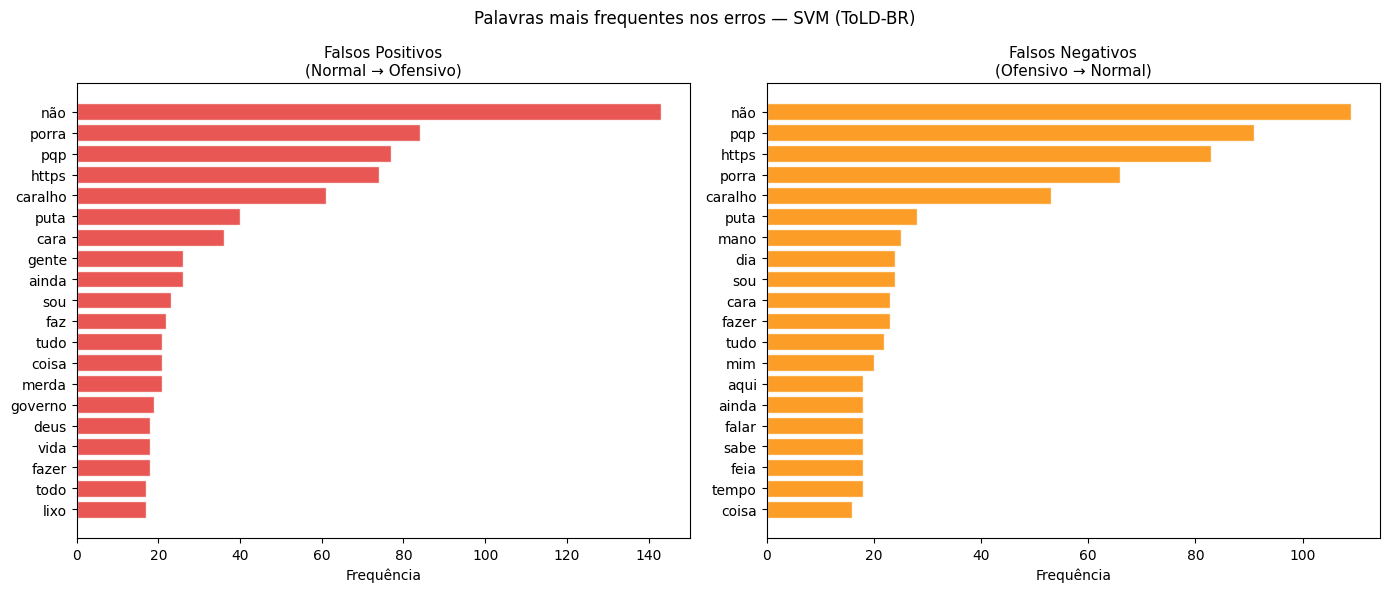

Figura salva: palavras_erros_svm_toldbr.png


In [12]:
# ANALISE_QUALITATIVA_PATCH_WORDS — gráfico de palavras (ToLD-BR)
import re as _re, matplotlib.pyplot as _plt
from collections import Counter as _Counter

STOPWORDS = {
    'de','a','o','que','e','do','da','em','um','para','é','com','uma','os','no',
    'se','na','por','mais','as','dos','como','mas','foi','ao','ele','das','tem',
    'à','seu','sua','ou','ser','quando','muito','há','nos','já','está','eu',
    'também','só','pelo','pela','até','isso','ela','entre','era','depois','sem',
    'mesmo','aos','ter','seus','quem','nas','me','esse','eles','estão','você',
    'tinha','foram','essa','num','nem','suas','meu','às','minha','têm','numa',
    'pelos','pelas','nesse','este','neste','rt','user','pra','vai','vou','aí',
    'lá','né','tá','tô','vc','vcs','pq','tb','tmb','mto','mta','kkk','kk',
}

def _top_words(texts, n=20):
    words = []
    for t in texts:
        toks = _re.findall(r'\b[a-záéíóúâêôãõç]{3,}\b', str(t).lower())
        words.extend([w for w in toks if w not in STOPWORDS])
    return _Counter(words).most_common(n)

_fp_texts = texts_qualitativa[(np.array(y_test) == 0) & (np.array(y_pred) == 1)]
_fn_texts = texts_qualitativa[(np.array(y_test) == 1) & (np.array(y_pred) == 0)]

_top_fp = _top_words(_fp_texts, n=20)
_top_fn = _top_words(_fn_texts, n=20)

_fig, (_ax1, _ax2) = _plt.subplots(1, 2, figsize=(14, 6))

if _top_fp:
    _w, _c = zip(*_top_fp)
    _ax1.barh(list(reversed(_w)), list(reversed(_c)), color='#E53935', alpha=0.85, edgecolor='white')
_ax1.set_title('Falsos Positivos\n(Normal → Ofensivo)', fontsize=11)
_ax1.set_xlabel('Frequência')

if _top_fn:
    _w, _c = zip(*_top_fn)
    _ax2.barh(list(reversed(_w)), list(reversed(_c)), color='#FB8C00', alpha=0.85, edgecolor='white')
_ax2.set_title('Falsos Negativos\n(Ofensivo → Normal)', fontsize=11)
_ax2.set_xlabel('Frequência')

_plt.suptitle('Palavras mais frequentes nos erros — SVM (ToLD-BR)', fontsize=12)
_plt.tight_layout()
_fig_path = 'palavras_erros_svm_toldbr.png'
_plt.savefig(_fig_path, dpi=150, bbox_inches='tight')
_plt.show()
print(f'Figura salva: {_fig_path}')